# INSTALL LIBRARIES

In [43]:
!pip install xgboost imbalanced-learn

# IMPORT LIBRARIES

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [45]:
def plot_conf_matrix(y_true, y_pred, model_name):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted No Default","Predicted Default"],
        yticklabels=["Actual No Default","Actual Default"]
    )

    plt.title("Confusion Matrix - " + model_name)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

# LOAD DATASET

In [46]:
df = pd.read_csv("accepted_2007_to_2018Q4.csv")

# select first 10000 rows
df = df.head(10000)

print(df.shape)

df.head()

(10000, 151)


/tmp/ipykernel_156/3219011397.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("accepted_2007_to_2018Q4.csv")


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600,3600,3600,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700,24700,24700,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000,20000,20000,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000,35000,35000,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400,10400,10400,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


# SELECT IMPORTANT VARIABLES

In [47]:
columns = [
    'loan_amnt',
    'term',
    'int_rate',
    'grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'purpose',
    'dti',
    'delinq_2yrs',
    'revol_util',
    'total_acc',
    'loan_status'
]

df = df[columns]

# TARGET VARIABLE CREATION

In [48]:
df = df[df['loan_status'].isin(['Fully Paid','Charged Off'])]

df['default'] = df['loan_status'].apply(
    lambda x: 1 if x == 'Charged Off' else 0
)

df.drop('loan_status', axis=1, inplace=True)

# DATA CLEANING

In [49]:
df.dropna(inplace=True)

df['int_rate'] = df['int_rate'].astype(str).str.replace('%','').astype(float)
df['revol_util'] = df['revol_util'].astype(str).str.replace('%','').astype(float)

# ENCODE CATEGORICAL VARIABLES

In [50]:
categorical_cols = [
    'term',
    'grade',
    'emp_length',
    'home_ownership',
    'verification_status',
    'purpose'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# FEATURE ENGINEERING

In [51]:
df['loan_income_ratio'] = df['loan_amnt'] / df['annual_inc']

# EXPLORATORY DATA ANALYSIS

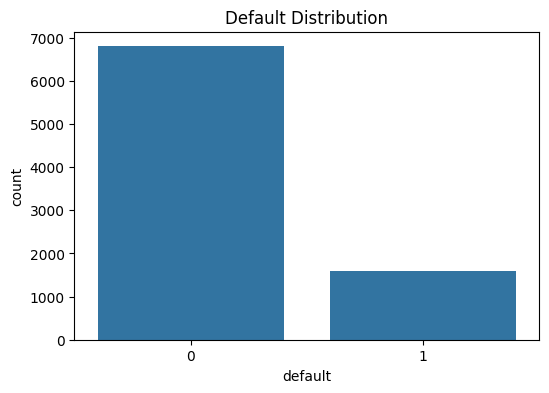

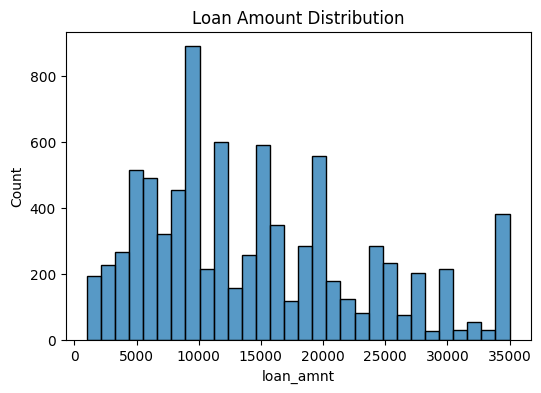

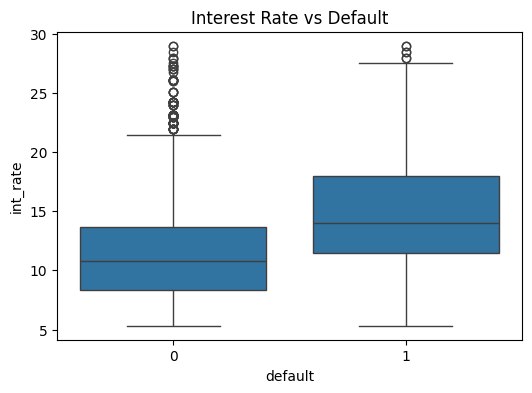

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df)
plt.title("Default Distribution")
plt.show()


plt.figure(figsize=(6,4))
sns.histplot(df['loan_amnt'], bins=30)
plt.title("Loan Amount Distribution")
plt.show()


plt.figure(figsize=(6,4))
sns.boxplot(x='default', y='int_rate', data=df)
plt.title("Interest Rate vs Default")
plt.show()

# TRAIN TEST SPLIT

In [53]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# HANDLE CLASS IMBALANCE USING SMOTE

In [54]:
sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)

# FEATURE SCALING

In [55]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# DEFINE MODELS



In [56]:
models = {

"Logistic Regression":
LogisticRegression(max_iter=2000),

"Decision Tree":
DecisionTreeClassifier(max_depth=6),

"Random Forest":
RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
),

"Gradient Boosting":
GradientBoostingClassifier(),

"XGBoost":
XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

}

# TRAIN AND EVALUATE MODELS


MODEL: Logistic Regression
Accuracy: 0.802263251935676
ROC AUC: 0.6907217685848824

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      1361
           1       0.44      0.17      0.24       318

    accuracy                           0.80      1679
   macro avg       0.64      0.56      0.56      1679
weighted avg       0.76      0.80      0.76      1679



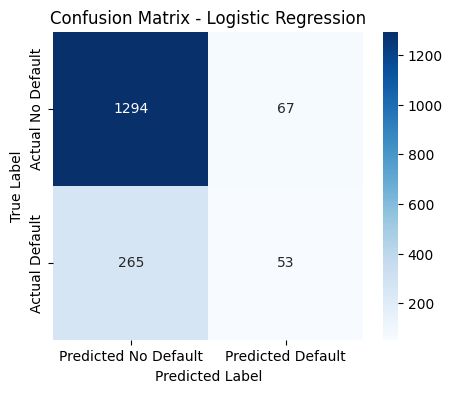


MODEL: Decision Tree
Accuracy: 0.7742703990470519
ROC AUC: 0.6818053687863622

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1361
           1       0.36      0.25      0.30       318

    accuracy                           0.77      1679
   macro avg       0.60      0.57      0.58      1679
weighted avg       0.75      0.77      0.76      1679



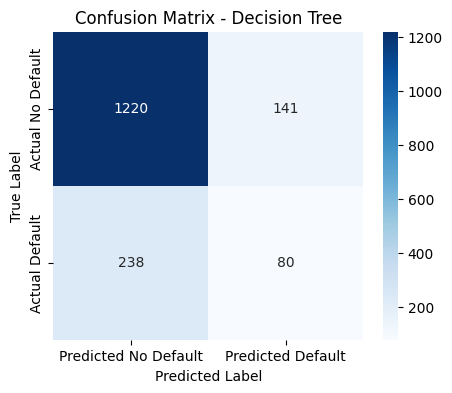


MODEL: Random Forest
Accuracy: 0.7820131030375224
ROC AUC: 0.7017384553533058

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1361
           1       0.39      0.27      0.32       318

    accuracy                           0.78      1679
   macro avg       0.62      0.58      0.59      1679
weighted avg       0.76      0.78      0.77      1679



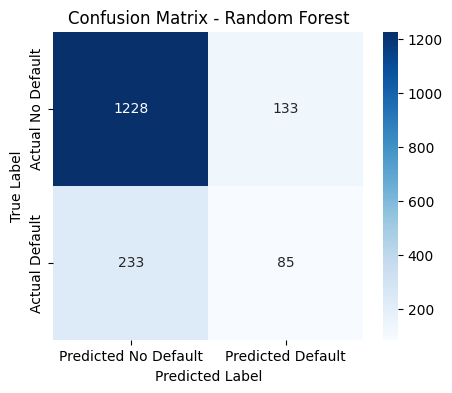


MODEL: Gradient Boosting
Accuracy: 0.798094103633115
ROC AUC: 0.7044937823187722

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1361
           1       0.44      0.24      0.31       318

    accuracy                           0.80      1679
   macro avg       0.64      0.59      0.60      1679
weighted avg       0.76      0.80      0.77      1679



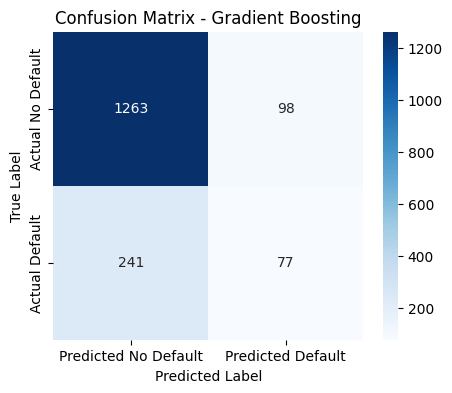


MODEL: XGBoost
Accuracy: 0.7986896962477665
ROC AUC: 0.6965050670289604

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1361
           1       0.43      0.19      0.26       318

    accuracy                           0.80      1679
   macro avg       0.63      0.56      0.57      1679
weighted avg       0.76      0.80      0.77      1679



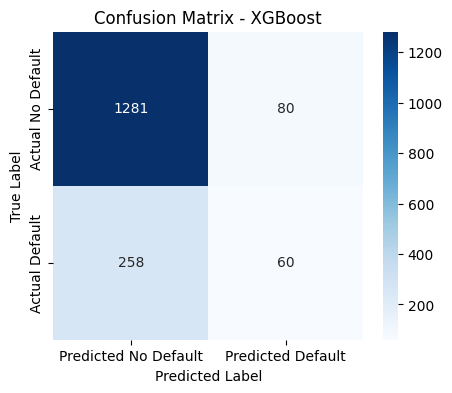

In [57]:
for name, model in models.items():

    print("\n============================")
    print("MODEL:", name)
    print("============================")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print("Accuracy:", acc)
    print("ROC AUC:", auc)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # show confusion matrix
    plot_conf_matrix(y_test, y_pred, name)

    results.append((name, acc, auc))

# MODEL COMPARISON TABLE

In [58]:
results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","ROC_AUC"]
)

print("\nModel Performance Comparison")
print(results_df)


Model Performance Comparison
                  Model  Accuracy   ROC_AUC
0   Logistic Regression  0.802263  0.690722
1         Decision Tree  0.774270  0.681805
2         Random Forest  0.782013  0.701738
3     Gradient Boosting  0.798094  0.704503
4               XGBoost  0.798690  0.696505
5   Logistic Regression  0.802263  0.690722
6         Decision Tree  0.774270  0.681805
7         Random Forest  0.782013  0.701738
8     Gradient Boosting  0.798094  0.704503
9               XGBoost  0.798690  0.696505
10  Logistic Regression  0.802263  0.690722
11        Decision Tree  0.774270  0.681805
12        Random Forest  0.782013  0.701738
13    Gradient Boosting  0.798094  0.704494
14              XGBoost  0.798690  0.696505


# ROC CURVE COMPARISON

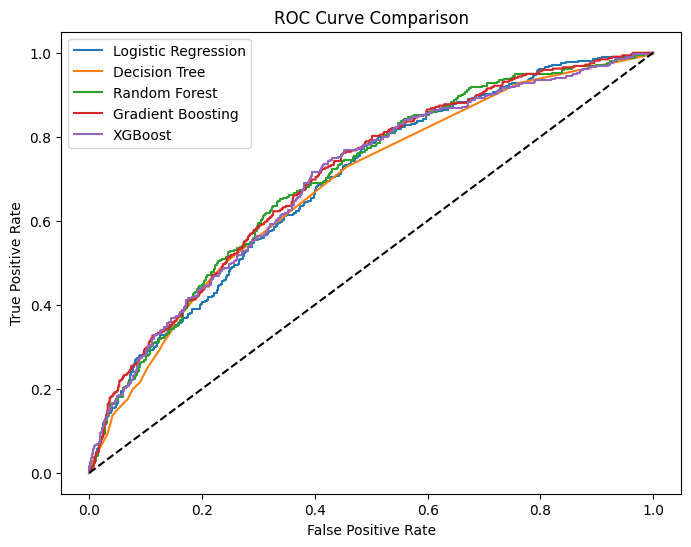

In [59]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

# PRECISION RECALL CURVE

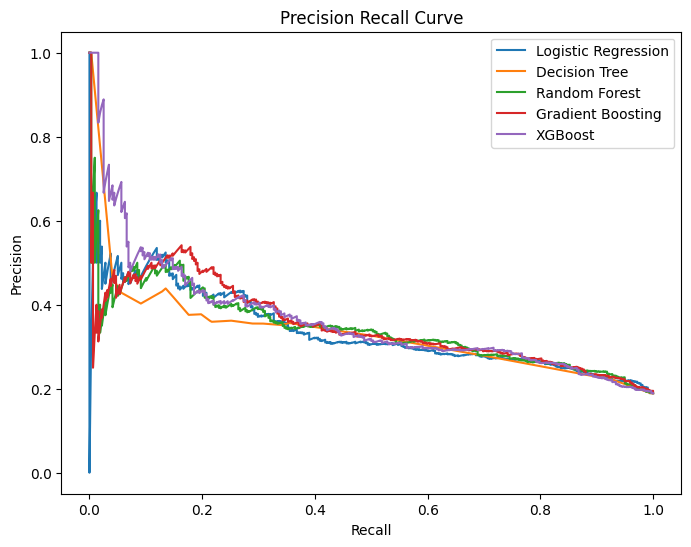

In [60]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")

plt.legend()

plt.show()

# FEATURE IMPORTANCE (Random Forest)

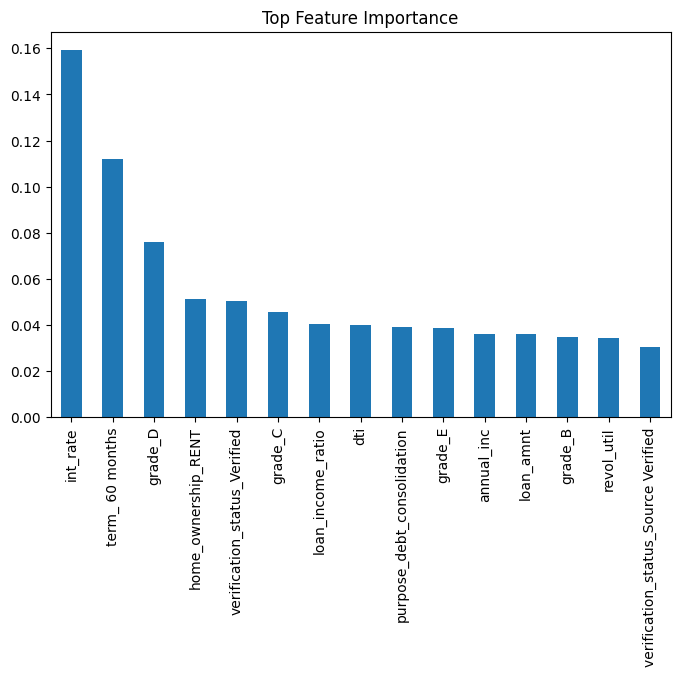

In [61]:
rf = models["Random Forest"]

importance = rf.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
)

top_features = feature_importance.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title("Top Feature Importance")
plt.show()

# CROSS VALIDATION

In [62]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("\nCross Validation AUC Scores")

print(cv_scores)

print("Average AUC:", cv_scores.mean())


Cross Validation AUC Scores
[0.72603616 0.72812788 0.74452563 0.69846698 0.72546939]
Average AUC: 0.7245252088985401
